In [3]:
# Setup and Imports
%load_ext autoreload
%autoreload 2

import sys
import os
from pathlib import Path

# Dynamically append the project root to sys.path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Import the modularized functions from your src/ directory
# (Assuming you wrapped your clean_dataset.py logic into a function called `clean_dataset`)
from src.clean_dataset import clean_dataset 
from src.split_raw_data import physical_train_test_split
from src.balance_dataset import balance_dataset_offline

# Define global paths for the pipeline
RAW_DATA_DIR = Path("../data/ALPUB_v2/images")
SPLIT_DATA_DIR = Path("../data/split_dataset")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Automated Cleaning Execution
print(f"Starting automated cleaning heuristics on {RAW_DATA_DIR}...")

# Execute the cleaning logic
# (If your clean_dataset is still a flat script, you can run it via `%run ../src/clean_dataset.py`)
clean_dataset(RAW_DATA_DIR)

print("Automated cleaning complete. Flagged images moved to subdirectories.")

Starting automated cleaning heuristics on ../data/ALPUB_v2/images...
 Starting for letter: Alpha
Alpha           [radical]  total=21200  white=7288  dark=2220  contrast=6078  gray= 187  review= 207  clean= 5220
 Starting for letter: Beta
Beta            [safe   ]  total= 1296  white= 183  dark= 212  contrast= 327  gray=  31  review=  47  clean=  496
 Starting for letter: Gamma
Gamma           [middle ]  total= 3721  white= 823  dark= 326  contrast=1683  gray=  32  review=  28  clean=  829
 Starting for letter: Delta
Delta           [middle ]  total= 5689  white=1435  dark= 670  contrast=1539  gray=  74  review=  79  clean= 1892
 Starting for letter: Epsilon
Epsilon         [radical]  total=14909  white=5221  dark=1419  contrast=4110  gray= 102  review= 125  clean= 3932
 Starting for letter: Zeta
Zeta            [safe   ]  total=  701  white= 135  dark=  65  contrast= 187  gray=  15  review=  25  clean=  274
 Starting for letter: Eta
Eta             [middle ]  total= 7348  white=1688  d

# STOP: MANUAL REVIEW CHECKPOINT

The automated cleaning script has aggressively filtered the dataset. Because our dataset is highly imbalanced, aggressive filtering might have accidentally removed valid samples of rare characters (e.g., Psi, Zeta, Xi).

**Action Required Before Proceeding:**
1. Open your file explorer and navigate to `../data/ALPUB_v2/images/`.
2. Inspect the rare character folders. The rarest characters are: **Psi**, **Xi**, **Zeta**, **Beta**
3. Look inside `_review_gray_blob` and `_flagged_low_contrast`.
4. If you spot a valid letter, manually move it **back** to its parent directory (e.g., move from `Psi/_flagged_low_contrast/img.jpg` back to `Psi/img.jpg`).

**Do not run the next cells until manual curation is complete!**

Note (Albert) - manual inspection increased "clean" data
- **Psi** 190 --> 252
- **Xi** 264 --> 316
- **Zeta** 274 --> 348
- **Beta** 496 --> 530


In [5]:
# Data Leakage Prevention (Physical Split)
print("Initiating physical train/test split to prevent data leakage...")

physical_train_test_split(
    raw_data_dir=RAW_DATA_DIR, 
    output_dir=SPLIT_DATA_DIR, 
    test_size=0.20
)

Initiating physical train/test split to prevent data leakage...


Splitting Classes: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:14<00:00,  1.63it/s]

Split complete! Data saved to ../data/split_dataset/train and ../data/split_dataset/test


In [6]:
# Offline Dataset Balancing (Train Set ONLY)
TRAIN_DIR = SPLIT_DATA_DIR / "train"

print(f"Balancing dataset by augmenting minority classes in {TRAIN_DIR}...")

# This will generate synthetic geometric clones until all classes equal the majority class
balance_dataset_offline(TRAIN_DIR)

print("Preprocessing Pipeline Complete! You may now proceed to 02_feature_extraction.ipynb.")

Balancing dataset by augmenting minority classes in ../data/split_dataset/train...
Target count per class: 4176 images
Augmenting Omicron: Generating 201 new images...


Augmenting Beta: Generating 3752 new images...


Augmenting Chi: Generating 2960 new images...


Augmenting Delta: Generating 2663 new images...


Augmenting Gamma: Generating 3513 new images...


...

Augmenting Upsilon: Generating 2299 new images...


Augmenting Theta: Generating 3053 new images...


Skipping Alpha (already at 4176)
Augmenting Tau: Generating 1621 new images...


Augmenting Phi: Generating 3281 new images...


Preprocessing Pipeline Complete! You may now proceed to 02_feature_extraction.ipynb.


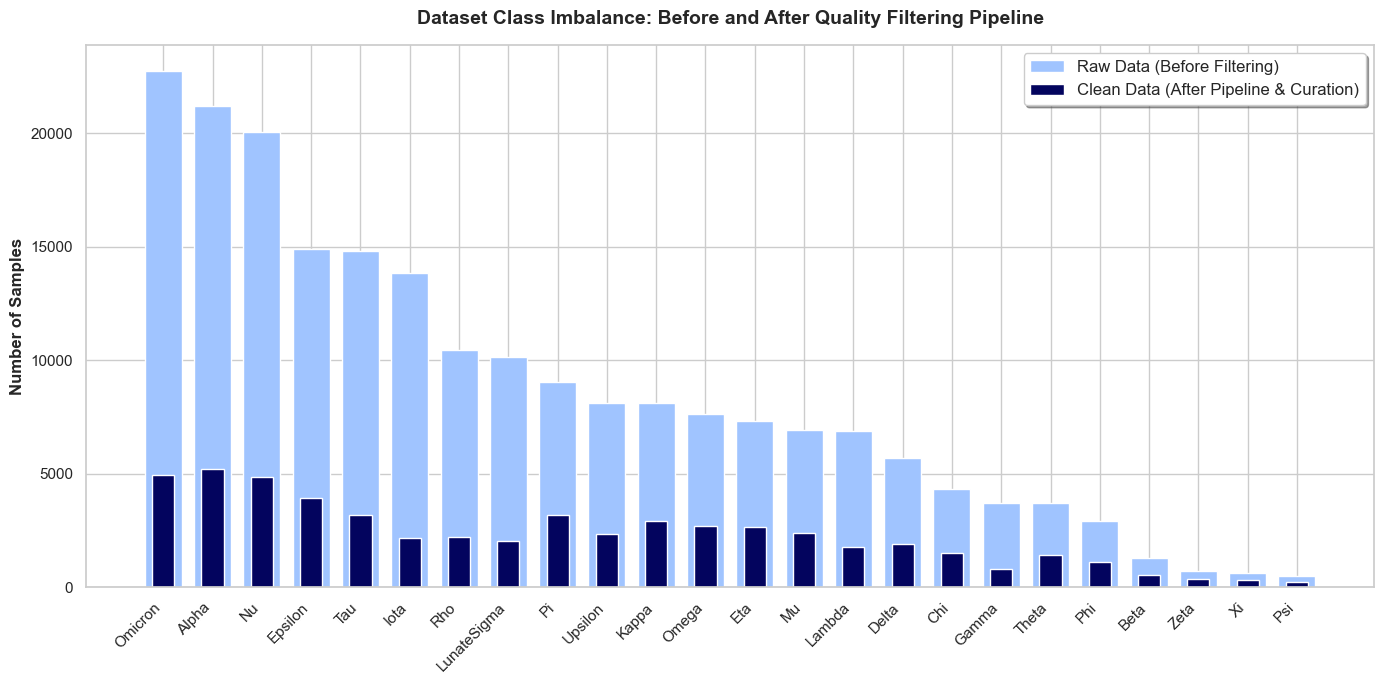

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Input Data (Includes manual adjustments for Psi, Xi, Zeta, Beta)
data = {
    "Alpha": (21200, 5220), "Beta": (1296, 530), "Gamma": (3721, 829), 
    "Delta": (5689, 1892), "Epsilon": (14909, 3932), "Zeta": (701, 348), 
    "Eta": (7348, 2666), "Theta": (3717, 1404), "Iota": (13830, 2165), 
    "Kappa": (8110, 2941), "Lambda": (6906, 1776), "Mu": (6924, 2396), 
    "Nu": (20056, 4875), "Xi": (641, 316), "Omicron": (22756, 4969), 
    "Pi": (9031, 3171), "Rho": (10453, 2239), "LunateSigma": (10151, 2022), 
    "Tau": (14817, 3194), "Upsilon": (8129, 2347), "Phi": (2930, 1119), 
    "Chi": (4329, 1520), "Psi": (513, 252), "Omega": (7640, 2715)
}

# 2. Sort data by Total Volume (Descending) for maximum visual impact
sorted_data = dict(sorted(data.items(), key=lambda item: item[1][0], reverse=True))

letters = list(sorted_data.keys())
total_counts = [val[0] for val in sorted_data.values()]
clean_counts = [val[1] for val in sorted_data.values()]

# 3. Setup the Plot Aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 4. Plot the Overlaid Bars
# We plot the "Total" bars first (wider and lighter), then "Clean" bars on top (narrower and darker)
x_pos = np.arange(len(letters))

# Raw Data (Background Bar)
plt.bar(x_pos, total_counts, width=0.75, color='#a0c4ff', label='Raw Data (Before Filtering)')

# Clean Data (Foreground Bar)
plt.bar(x_pos, clean_counts, width=0.45, color='#03045e', label='Clean Data (After Pipeline & Curation)')

# 5. Formatting and Labels
plt.xticks(x_pos, letters, rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.title('Dataset Class Imbalance: Before and After Quality Filtering Pipeline', 
          fontsize=14, fontweight='bold', pad=15)

# Optimize Legend and Layout
plt.legend(fontsize=12, loc='upper right', frameon=True, shadow=True)
plt.tight_layout()

# 6. Export for the Report
plt.savefig('dataset_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()